In [3]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-06-20 10:01:43.895501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781949704.081738      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781949704.136916      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781949704.589076      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781949704.589131      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781949704.589134      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

import os

classes = sorted(os.listdir(dataset_path))

print("Количество классов:", len(classes))
print(classes[:10])

Количество классов: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


Модель 1 - MobileNetV2

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model_mobile = Model(
    inputs=base_model.input,
    outputs=predictions
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model_mobile.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model_mobile.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history_mobile = model_mobile.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3


I0000 00:00:1781950020.070423     161 service.cc:152] XLA service 0x79355810f2c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781950020.070463     161 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781950020.070467     161 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781950021.170887     161 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-20 10:07:09.886748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:07:10.024139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1781950031.814291     161 device_co

213/517 ━━━━━━━━━━━━━━━━━━━━ 2:29 492ms/step - accuracy: 0.4946 - loss: 1.6838

2026-06-20 10:09:04.724153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:09:04.877538: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:09:05.014199: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.6296 - loss: 1.2407

2026-06-20 10:13:01.029958: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:13:01.165951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


517/517 ━━━━━━━━━━━━━━━━━━━━ 369s 680ms/step - accuracy: 0.7620 - loss: 0.7987 - val_accuracy: 0.8561 - val_loss: 0.4732
Epoch 2/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 470ms/step - accuracy: 0.8754 - loss: 0.4033 - val_accuracy: 0.8768 - val_loss: 0.3933
Epoch 3/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 237s 458ms/step - accuracy: 0.8963 - loss: 0.3336 - val_accuracy: 0.8828 - val_loss: 0.3561


In [12]:
print(
    "Лучшая точность MobileNetV2:",
    max(history_mobile.history['val_accuracy'])
)

Лучшая точность MobileNetV2: 0.8828238844871521


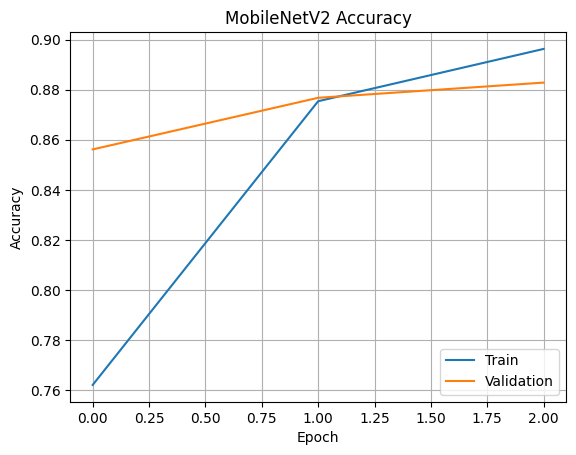

In [13]:
import matplotlib.pyplot as plt

plt.plot(history_mobile.history['accuracy'])
plt.plot(history_mobile.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='lower right'
)

plt.grid(True)

plt.show()

In [14]:
model_mobile.save(
    "/kaggle/working/MobileNetV2.keras"
)

Модель 2 - ResNet50

In [17]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

In [18]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model_resnet = Model(
    inputs=base_model.input,
    outputs=predictions
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
model_resnet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,618,447 (90.10 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
history_resnet = model_resnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 300s 556ms/step - accuracy: 0.1658 - loss: 2.5309 - val_accuracy: 0.2162 - val_loss: 2.3840
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 254s 492ms/step - accuracy: 0.2292 - loss: 2.3691 - val_accuracy: 0.2511 - val_loss: 2.2958
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 242s 467ms/step - accuracy: 0.2583 - loss: 2.2971 - val_accuracy: 0.2635 - val_loss: 2.2449
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 470ms/step - accuracy: 0.2757 - loss: 2.2443 - val_accuracy: 0.2986 - val_loss: 2.1786
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 470ms/step - accuracy: 0.2931 - loss: 2.2051 - val_accuracy: 0.3537 - val_loss: 2.1392


In [22]:
print(
    "Лучшая точность ResNet50:",
    max(history_resnet.history['val_accuracy'])
)

Лучшая точность ResNet50: 0.3537117838859558


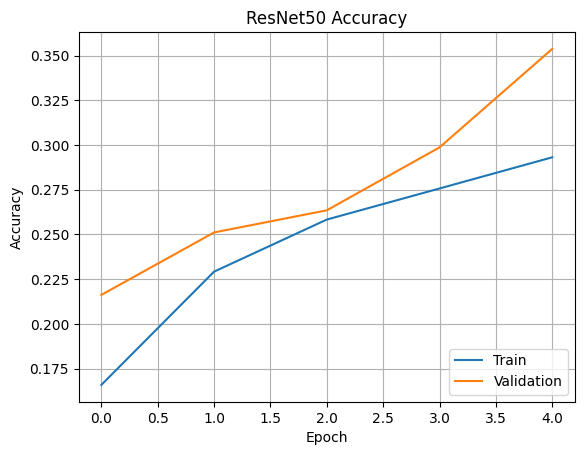

In [23]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])

plt.title('ResNet50 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='lower right'
)

plt.grid(True)

plt.show()

In [24]:
model_resnet.save(
    "/kaggle/working/ResNet50.keras"
)

In [30]:
from tensorflow.keras import mixed_precision
print(mixed_precision.global_policy())

<DTypePolicy "float32">


Модель 3 - EfficientNetB0

In [32]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

In [33]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model_eff = Model(
    inputs=base_model.input,
    outputs=predictions
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
model_eff.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
model_eff.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [36]:
history_eff = model_eff.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5


2026-06-20 10:59:50.960426: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:59:51.105233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:59:51.465990: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:59:51.608226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 10:59:52.448153: E external/local_xla/xla/stream_

317/517 ━━━━━━━━━━━━━━━━━━━━ 1:34 472ms/step - accuracy: 0.1333 - loss: 2.6206

2026-06-20 11:02:32.837700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:02:32.973120: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:02:33.285398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:02:33.426794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:02:34.222052: E external/local_xla/xla/stream_

517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.1343 - loss: 2.6168

2026-06-20 11:04:57.612554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:04:57.755631: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:04:58.097469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:04:58.239564: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 11:04:59.011201: E external/local_xla/xla/stream_

517/517 ━━━━━━━━━━━━━━━━━━━━ 326s 587ms/step - accuracy: 0.1383 - loss: 2.6081 - val_accuracy: 0.1555 - val_loss: 2.5902
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 241s 467ms/step - accuracy: 0.1381 - loss: 2.6024 - val_accuracy: 0.1031 - val_loss: 2.5799
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 240s 463ms/step - accuracy: 0.1442 - loss: 2.5978 - val_accuracy: 0.1555 - val_loss: 2.5821
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 236s 456ms/step - accuracy: 0.1437 - loss: 2.5978 - val_accuracy: 0.1555 - val_loss: 2.5729
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 240s 464ms/step - accuracy: 0.1432 - loss: 2.6019 - val_accuracy: 0.1555 - val_loss: 2.5981


In [37]:
print(
    "Лучшая точность EfficientNetB0:",
    max(history_eff.history['val_accuracy'])
)

Лучшая точность EfficientNetB0: 0.15550702810287476


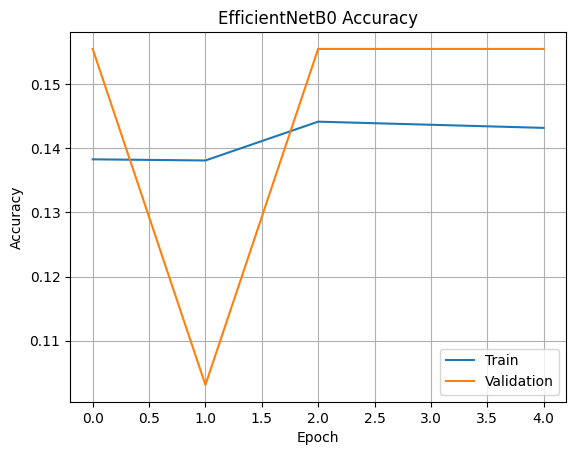

In [38]:
import matplotlib.pyplot as plt

plt.plot(history_eff.history['accuracy'])
plt.plot(history_eff.history['val_accuracy'])

plt.title('EfficientNetB0 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='lower right'
)

plt.grid(True)

plt.show()

In [39]:
model_eff.save(
    "/kaggle/working/EfficientNetB0.keras"
)

Модель 4 - DenseNet121

In [42]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

In [43]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model_dense = Model(
    inputs=base_model.input,
    outputs=predictions
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
model_dense.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
history_dense = model_dense.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 331s 586ms/step - accuracy: 0.6083 - loss: 1.2604 - val_accuracy: 0.8282 - val_loss: 0.6376
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 251s 486ms/step - accuracy: 0.7785 - loss: 0.6908 - val_accuracy: 0.8617 - val_loss: 0.4916
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 243s 470ms/step - accuracy: 0.8111 - loss: 0.5806 - val_accuracy: 0.8789 - val_loss: 0.4008
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 245s 474ms/step - accuracy: 0.8248 - loss: 0.5384 - val_accuracy: 0.8763 - val_loss: 0.3931
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 240s 464ms/step - accuracy: 0.8323 - loss: 0.5066 - val_accuracy: 0.8957 - val_loss: 0.3563


In [50]:
print(
    "Лучшая точность DenseNet121:",
    max(history_dense.history['val_accuracy'])
)

Лучшая точность DenseNet121: 0.8956816792488098


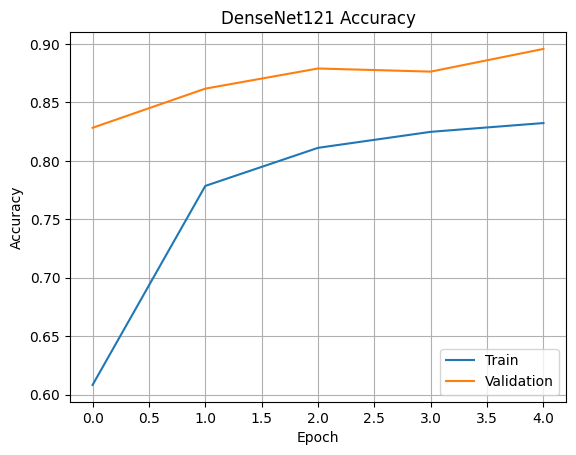

In [51]:
import matplotlib.pyplot as plt

plt.plot(history_dense.history['accuracy'])
plt.plot(history_dense.history['val_accuracy'])

plt.title('DenseNet121 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='lower right'
)

plt.grid(True)

plt.show()

In [52]:
model_dense.save(
    "/kaggle/working/DenseNet121.keras"
)

Модель 5 - InceptionV3

In [53]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

In [54]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

predictions = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model_inception = Model(
    inputs=base_model.input,
    outputs=predictions
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [57]:
model_inception.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
model_inception.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,833,519 (83.29 MB)

 Trainable params: 30,735 (120.06 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [59]:
history_inception = model_inception.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 280s 511ms/step - accuracy: 0.6383 - loss: 1.1275 - val_accuracy: 0.7746 - val_loss: 0.7011
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 239s 462ms/step - accuracy: 0.7613 - loss: 0.7341 - val_accuracy: 0.8079 - val_loss: 0.5783
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 242s 467ms/step - accuracy: 0.7855 - loss: 0.6469 - val_accuracy: 0.7996 - val_loss: 0.5751
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 244s 473ms/step - accuracy: 0.7953 - loss: 0.6163 - val_accuracy: 0.8307 - val_loss: 0.4937
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 240s 464ms/step - accuracy: 0.8029 - loss: 0.5886 - val_accuracy: 0.8360 - val_loss: 0.4778


In [60]:
print(
    "Лучшая точность InceptionV3:",
    max(history_inception.history['val_accuracy'])
)

Лучшая точность InceptionV3: 0.8360019326210022


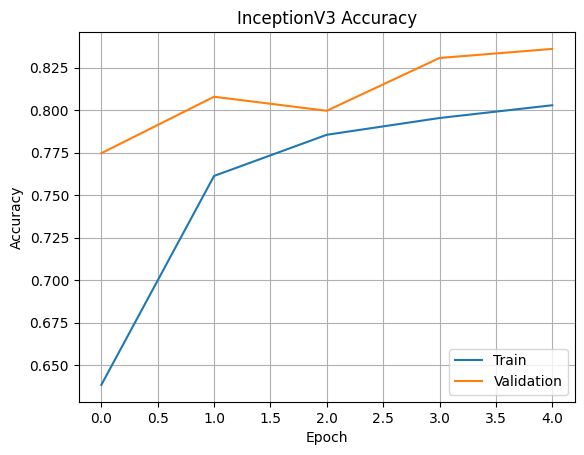

In [61]:
import matplotlib.pyplot as plt

plt.plot(history_inception.history['accuracy'])
plt.plot(history_inception.history['val_accuracy'])

plt.title('InceptionV3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train', 'Validation'],
    loc='lower right'
)

plt.grid(True)

plt.show()

In [62]:
model_inception.save(
    "/kaggle/working/InceptionV3.keras"
)